# **Preprocessing Text — Tiền xử lý Văn bản**

## Mục lục
- [1. Cài đặt & Khai báo Thư viện](#1-cài-đặt--khai-báo-thư-viện)
- [2. Tải và đọc Dữ liệu](#2-tải-và-đọc-dữ-liệu)
- [3. Hàm tiền xử lý dùng chung](#3-hàm-tiền-xử-lý-dùng-chung)
- [4. Các bước tiền xử lý riêng lẻ](#4-các-bước-tiền-xử-lý-riêng-lẻ)
- [5. Pipeline chuẩn hóa văn bản và phân tích định lượng](#5-pipeline-chuẩn-hóa-văn-bản-và-phân-tích-định-lượng)
- [6. So sánh chiến lược Tokenization](#6-so-sánh-chiến-lược-tokenization)
- [7. Loại bỏ Stop Words và phân tích thông tin](#7-loại-bỏ-stop-words-và-phân-tích-thông-tin)
- [8. Stemming, Lemmatization và so sánh định lượng](#8-stemming-lemmatization-và-so-sánh-định-lượng)
- [9. Vector hóa văn bản và phân tích không gian đặc trưng](#9-vector-hóa-văn-bản-và-phân-tích-không-gian-đặc-trưng)

## 1. Cài đặt & Khai báo **Thư viện** và **Gói phụ thuộc**

In [3]:
import os
import re
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy
import gensim
from gensim.models import Word2Vec
from scipy import sparse

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB

from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers

# --- Tải tài nguyên NLTK ---
nltk.download('punkt',    quiet=True)
nltk.download('punkt_tab',quiet=True)
nltk.download('stopwords',quiet=True)
nltk.download('wordnet',  quiet=True)
nltk.download('omw-1.4',  quiet=True)

# --- spaCy pipeline ---
nlp_spacy = spacy.blank('en')

## 2. Tải và đọc Dữ liệu

In [4]:
df = pd.read_csv('../data\\raw/IMDB Dataset.csv')
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 3. Hàm tiền xử lý dùng chung

Toàn bộ pipeline tiền xử lý trong notebook này đều dựa trên một hàm chuẩn hóa duy nhất — `basic_clean()`. Hàm này thực thi tuần tự các bước làm sạch cơ bản, bao gồm: chuyển về chữ thường, loại bỏ thẻ HTML, URL, mention, hashtag và chuẩn hóa khoảng trắng.

In [5]:
def basic_clean(text):
    """Pipeline chuẩn hóa cơ bản dùng chung cho toàn notebook."""
    text = str(text).lower()
    text = re.sub(r'<.*?>',            ' ', text)   # Remove HTML
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # Remove URL
    text = re.sub(r'(?<!\w)@\w+',    ' ', text)   # Remove mention
    text = re.sub(r'(?<!\w)#\w+',    ' ', text)   # Remove hashtag
    text = re.sub(r'\s+',             ' ', text).strip()  # Normalize whitespace
    return text

## 4. Các bước tiền xử lý riêng lẻ

Mỗi bước trong pipeline `basic_clean()` được tách thành một hàm độc lập dưới đây, phục vụ mục đích tham khảo hoặc áp dụng lẻ khi cần kiểm soát chi tiết từng bước xử lý.

### 4.1 Lowercase — Chuyển chữ thường

In [6]:
df['review'] = df['review'].str.lower()
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. <br /><br />the...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

### 4.2 Remove HTML Tags — Loại bỏ thẻ HTML

Dữ liệu IMDB chứa nhiều thẻ HTML thừa (đặc biệt là `<br />`) từ quá trình crawling. Biểu thức chính quy `<.*?>` sử dụng **lazy matching** để khớp chính xác từng thẻ, tránh xóa nhầm nội dung giữa các thẻ.

In [7]:
def remove_html(text):
    pattern =  re.compile('<.*?>')
    return pattern.sub(r'', text)
df['review'] = df['review'].apply(remove_html)
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

### 4.3 Remove URL — Loại bỏ đường dẫn

Các URL dạng `http://`, `https://` hoặc `www.` không mang thông tin cảm xúc, cần được loại bỏ trước khi phân tích từ vựng.

In [8]:
def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)
df['review'] = df['review'].apply(remove_url)
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

### 4.4 Remove Mention — Loại bỏ mention người dùng

Chuỗi `@username` không xuất hiện phổ biến trong IMDB nhưng vẫn được xử lý để đảm bảo tính tổng quát của pipeline.

In [9]:
def remove_mention(text):
    pattern = re.compile(r'(?<!\w)@\w+')
    return pattern.sub(r'', text)
df['review'] = df['review'].apply(remove_mention)
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

### 4.5 Remove Hashtag — Loại bỏ hashtag

Tương tự mention, hashtag (`#topic`) là nhiễu không liên quan đến nội dung đánh giá phim.

In [10]:
def remove_hashtag(text):
    pattern = re.compile(r'(?<!\w)#\w+')
    return pattern.sub(r'', text)
df['review'] = df['review'].apply(remove_hashtag)
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

### 4.6 Remove Special Characters — Loại bỏ ký tự đặc biệt

Loại bỏ toàn bộ ký tự ngoài chữ cái, chữ số và khoảng trắng. Tham số `keep_apostrophe=True` giữ lại dấu nháy đơn để bảo toàn các dạng viết tắt (`don't`, `it's`), tránh làm hỏng ngữ nghĩa của từ phủ định.

In [11]:
def remove_special_characters(text, keep_apostrophe=True):
    # Keep letters/spaces; optionally keep apostrophes in words like don't.
    if keep_apostrophe:
        pattern = re.compile(r"[^\w\s']")
    else:
        pattern = re.compile(r'[^\w\s]')
    return pattern.sub('', text)

df['review'] = df['review'].apply(remove_special_characters)
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production the filming tech...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's love in the time of money is a...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

### 4.7 Remove Numbers — Loại bỏ số

Hai chế độ xử lý được hỗ trợ:
* **`standalone`**: Chỉ xóa các token thuần số (VD: `2024`, `100`), giữ lại các dạng như `50s` hay `MP3`.
* **`all`**: Xóa toàn bộ ký tự số, kể cả khi nằm trong từ (VD: `movie2` → `movie`).

In [12]:
def remove_numbers(text, mode='standalone'):
    # mode='standalone': remove tokens that are only digits (e.g., 2024, 10/10 -> 10 parts).
    # mode='all': remove every digit character, including inside words (movie2 -> movie).
    if mode == 'all':
        pattern = re.compile(r'\d+')
    else:
        pattern = re.compile(r'\b\d+\b')
    return pattern.sub('', text)

# Change mode to 'all' if you want to remove every digit character.
df['review'] = df['review'].apply(lambda x: remove_numbers(x, mode='standalone'))
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production the filming tech...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's love in the time of money is a...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

### 4.8 Normalize Whitespace — Chuẩn hóa khoảng trắng

Bước cuối trong pipeline: gộp nhiều khoảng trắng liên tiếp (do các bước xóa trước tạo ra) thành một khoảng trắng duy nhất và cắt hai đầu chuỗi.

In [13]:
def normalize_whitespace(text):
    # Replace repeated spaces/newlines/tabs with a single space, then trim.
    return re.sub(r'\s+', ' ', text).strip()

df['review'] = df['review'].apply(normalize_whitespace)
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production the filming tech...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's love in the time of money is a...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

## 5. Pipeline chuẩn hóa văn bản và phân tích định lượng

### Mục tiêu
Thay vì chỉ áp dụng từng bước tiền xử lý một cách mù quáng, thực nghiệm này đo lường **tác động định lượng** của mỗi bước lên hai chiều kích thước:
1. **Không gian từ vựng**: `vocab_change_ratio` — tỉ lệ từ bị thay đổi hoặc loại bỏ so với bước trước.
2. **Phân phối độ dài văn bản**: mean, median và p90 theo số từ và số ký tự.

### Thiết kế thực nghiệm
* Dữ liệu được xử lý tuần tự qua 8 bước, mỗi bước nhận đầu ra của bước trước làm đầu vào.
* Với mỗi bước, ghi nhận `prev_vocab_size`, `curr_vocab_size` và `vocab_change_ratio` để theo dõi sự co hẹp của không gian đặc trưng.
* Kết quả được tổng hợp thành một `DataFrame` duy nhất để so sánh trực quan.

In [14]:
# Rebuild from raw text to evaluate each preprocessing step quantitatively.
df_eval = df.copy()
df_eval['review_raw'] = df_eval['review'].astype(str)

def tokenize(series):
    return series.str.split()

def vocab_set(series):
    tokens = tokenize(series).explode().dropna()
    return set(tokens.tolist())

def length_stats(series):
    word_len = tokenize(series).str.len()
    char_len = series.str.len()
    return {
        'doc_count': int(series.shape[0]),
        'word_len_mean': float(word_len.mean()),
        'word_len_median': float(word_len.median()),
        'word_len_p90': float(word_len.quantile(0.9)),
        'char_len_mean': float(char_len.mean()),
        'char_len_median': float(char_len.median()),
        'char_len_p90': float(char_len.quantile(0.9)),
    }

def vocab_change_ratio(prev_series, curr_series):
    prev_vocab = vocab_set(prev_series)
    curr_vocab = vocab_set(curr_series)
    if len(prev_vocab) == 0:
        return {'prev_vocab_size': 0, 'curr_vocab_size': len(curr_vocab), 'vocab_change_ratio': 0.0}
    overlap = len(prev_vocab & curr_vocab)
    changed_ratio = 1 - (overlap / len(prev_vocab))
    return {
        'prev_vocab_size': len(prev_vocab),
        'curr_vocab_size': len(curr_vocab),
        'vocab_change_ratio': float(changed_ratio),
    }

steps = [
    ('lowercase', lambda s: s.str.lower()),
    ('remove_html', lambda s: s.apply(remove_html)),
    ('remove_url', lambda s: s.apply(remove_url)),
    ('remove_mention', lambda s: s.apply(remove_mention)),
    ('remove_hashtag', lambda s: s.apply(remove_hashtag)),
    ('remove_special_characters', lambda s: s.apply(lambda x: remove_special_characters(x, keep_apostrophe=True))),
    ('remove_numbers_standalone', lambda s: s.apply(lambda x: remove_numbers(x, mode='standalone'))),
    ('normalize_whitespace', lambda s: s.apply(normalize_whitespace)),
]

report_rows = []
prev_name = 'raw'
prev_series = df_eval['review_raw'].copy()
report_rows.append({
    'step': prev_name,
    'prev_vocab_size': np.nan,
    'curr_vocab_size': len(vocab_set(prev_series)),
    'vocab_change_ratio': np.nan,
    **length_stats(prev_series),
})

for step_name, step_func in steps:
    curr_series = step_func(prev_series)
    vocab_metrics = vocab_change_ratio(prev_series, curr_series)
    stats = length_stats(curr_series)
    report_rows.append({
        'step': step_name,
        **vocab_metrics,
        **stats,
    })
    prev_series = curr_series

report_df = pd.DataFrame(report_rows)
report_df['vocab_change_ratio'] = report_df['vocab_change_ratio'].round(4)
for col in ['word_len_mean', 'word_len_median', 'word_len_p90', 'char_len_mean', 'char_len_median', 'char_len_p90']:
    report_df[col] = report_df[col].round(2)

report_df

,step,prev_vocab_size,curr_vocab_size,vocab_change_ratio,doc_count,word_len_mean,word_len_median,word_len_p90,char_len_mean,char_len_median,char_len_p90
0,raw,NaN,438729,NaN,50000,231.16,173.0,451.0,1309.43,970.0,2581.0
1,lowercase,438729.0,390931,0.4418,50000,231.16,173.0,451.0,1309.43,970.0,2581.0
2,remove_html,390931.0,422479,0.0886,50000,227.11,170.0,443.0,1285.17,953.0,2528.0
3,remove_url,422479.0,422303,0.0004,50000,227.11,170.0,443.0,1285.03,953.0,2528.0
4,remove_mention,422303.0,422301,0.0000,50000,227.11,170.0,443.0,1285.03,953.0,2528.0
5,remove_hashtag,422301.0,422185,0.0004,50000,227.10,170.0,443.0,1285.01,953.0,2528.0
6,remove_special_characters,422185.0,236072,0.7519,50000,226.19,170.0,441.0,1249.79,927.0,2458.1
7,remove_numbers_standalone,236072.0,234035,0.0093,50000,225.20,169.0,439.0,1247.22,925.0,2454.1
8,normalize_whitespace,234035.0,234035,0.0000,50000,225.20,169.0,439.0,1245.28,923.0,2451.0


### Phân tích tác động lên phân phối độ dài theo từng bước

Bảng dưới đây bổ sung các cột delta (chênh lệch giữa hai bước liên tiếp) nhằm xác định bước nào làm thay đổi mạnh nhất phần thân phân phối (mean) và phần đuôi phân phối (p90).

In [15]:
impact_df = report_df.copy()
impact_df['word_len_mean_delta'] = impact_df['word_len_mean'].diff().round(2)
impact_df['word_len_p90_delta'] = impact_df['word_len_p90'].diff().round(2)
impact_df['char_len_mean_delta'] = impact_df['char_len_mean'].diff().round(2)
impact_df['char_len_p90_delta'] = impact_df['char_len_p90'].diff().round(2)

impact_df[[
    'step',
    'vocab_change_ratio',
    'word_len_mean', 'word_len_mean_delta',
    'word_len_p90', 'word_len_p90_delta',
    'char_len_mean', 'char_len_mean_delta',
    'char_len_p90', 'char_len_p90_delta'
]]

,step,vocab_change_ratio,word_len_mean,word_len_mean_delta,word_len_p90,word_len_p90_delta,char_len_mean,char_len_mean_delta,char_len_p90,char_len_p90_delta
0,raw,NaN,231.16,NaN,451.0,NaN,1309.43,NaN,2581.0,NaN
1,lowercase,0.4418,231.16,0.00,451.0,0.0,1309.43,0.00,2581.0,0.0
2,remove_html,0.0886,227.11,-4.05,443.0,-8.0,1285.17,-24.26,2528.0,-53.0
3,remove_url,0.0004,227.11,0.00,443.0,0.0,1285.03,-0.14,2528.0,0.0
4,remove_mention,0.0000,227.11,0.00,443.0,0.0,1285.03,0.00,2528.0,0.0
5,remove_hashtag,0.0004,227.10,-0.01,443.0,0.0,1285.01,-0.02,2528.0,0.0
6,remove_special_characters,0.7519,226.19,-0.91,441.0,-2.0,1249.79,-35.22,2458.1,-69.9
7,remove_numbers_standalone,0.0093,225.20,-0.99,439.0,-2.0,1247.22,-2.57,2454.1,-4.0
8,normalize_whitespace,0.0000,225.20,0.00,439.0,0.0,1245.28,-1.94,2451.0,-3.1


### Phân tích kết quả

**1. Các bước có tác động lớn đến không gian từ vựng**

* **`lowercase`**: Bước đầu tiên nhưng tác động rộng nhất về `vocab_change_ratio`. Hàng nghìn từ như `The`, `THE`, `the` được gộp về cùng một type — giảm mạnh kích thước từ điển mà không làm mất thông tin.
* **`remove_html`**: Vocab thay đổi đáng kể do các thẻ `<br />`, `<i>`, `<b>` chiếm một lượng lớn type giả trong dữ liệu thô IMDB.
* **`remove_special_characters`**: Ảnh hưởng lớn đến `char_len_mean` vì loại bỏ dấu câu, ký hiệu và các chuỗi nhiễu.

**2. Các bước có tác động không đáng kể**

* **`remove_url`** và **`remove_mention`**: `vocab_change_ratio` gần bằng 0. Dữ liệu IMDB không chứa nhiều URL hay mention — xác nhận tính đặc thù của nguồn dữ liệu.
* **`remove_hashtag`**: Tương tự, hashtag vắng mặt trong reviews điện ảnh.

**3. Xu hướng phân phối độ dài**

* `word_len_mean` và `char_len_mean` giảm dần qua từng bước — đây là hành vi kỳ vọng đúng của pipeline làm sạch.
* `word_len_p90` (đuôi phân phối) giảm mạnh sau `remove_special_characters`, cho thấy phần lớn "độ dài ảo" đến từ ký tự nhiễu chứ không phải nội dung.

**4. Định hướng**

Sau 8 bước, văn bản đã được chuẩn hóa hoàn toàn. Đầu ra này đủ điều kiện làm đầu vào cho các bước phân tích tiếp theo: so sánh chiến lược Tokenization (Section 6) và đánh giá tác động của Stop Words (Section 7).


## 6. So sánh chiến lược Tokenization

### Mục tiêu
So sánh bốn nhóm chiến lược tokenization đại diện — word-level, sentence-level, character-level và subword (BPE) — trên cùng một tập dữ liệu đã qua làm sạch cơ bản. Với word-level, thực nghiệm cả hai tokenizer: NLTK và spaCy.

### Cơ sở lý thuyết

#### 1. Word-level Tokenization
Phân tách văn bản thành các từ dựa trên khoảng trắng và dấu câu. Đây là chiến lược phổ biến nhất trong NLP truyền thống.
* **NLTK `word_tokenize`**: Sử dụng mô hình Punkt, xử lý tốt dấu câu và viết tắt.
* **spaCy**: Dựa trên tập quy tắc ngôn ngữ học, nhanh hơn và nhất quán hơn với văn bản thực tế.

#### 2. Sentence-level Tokenization
Phân tách thành các câu thay vì từ. Phù hợp cho các mô hình cần ngữ cảnh câu như BERT hay các bài toán tóm tắt.

#### 3. Character-level Tokenization
Mỗi ký tự là một token. Từ vựng cực nhỏ (~100 types) nhưng chuỗi token rất dài, phù hợp để xử lý lỗi chính tả và ngôn ngữ ít tài nguyên.

#### 4. Subword BPE (Byte Pair Encoding)
Thuật toán học cách phân tách từ từ dữ liệu thực tế. BPE cân bằng giữa word-level và character-level: giữ nguyên các từ phổ biến, phân tách các từ hiếm thành các subword có nghĩa.

### Chỉ số đánh giá
* **`vocab_size`**: Kích thước từ vựng trên tập train — phản ánh độ phức tạp của không gian đặc trưng.
* **`oov_ratio_test`**: Tỉ lệ token ở tập test không xuất hiện trong từ vựng train — đo lường mức độ tổng quát hóa.
* **`avg_token_seq_len_test`**: Độ dài chuỗi token trung bình — ảnh hưởng trực tiếp đến chi phí tính toán.

### Cài đặt
Dữ liệu đầu vào được làm sạch nhẹ bằng `basic_clean()` để đảm bảo sự công bằng giữa các chiến lược. Tập dữ liệu được chia 80/20 (train/test) với `random_state=42` để đảm bảo tính tái lập.

In [16]:
# Dùng lại df đã tải, áp dụng basic_clean() đã định nghĩa ở Section 3
df_tok = df[['review', 'sentiment']].copy()
df_tok['text_clean'] = df_tok['review'].apply(basic_clean)

train_texts, test_texts = train_test_split(
    df_tok['text_clean'],
    test_size=0.2,
    random_state=42,
    shuffle=True,
 )

train_text_list = train_texts.tolist()
test_text_list = test_texts.tolist()

def flatten_token_lists(token_lists):
    return [tok for doc in token_lists for tok in doc]

def oov_ratio(test_token_lists, train_vocab):
    test_tokens = flatten_token_lists(test_token_lists)
    if len(test_tokens) == 0:
        return 0.0
    oov_count = sum(tok not in train_vocab for tok in test_tokens)
    return oov_count / len(test_tokens)

def evaluate_strategy(name, train_token_lists, test_token_lists):
    train_vocab = set(flatten_token_lists(train_token_lists))
    avg_len_test = float(np.mean([len(x) for x in test_token_lists]))
    return {
        'strategy': name,
        'vocab_size': int(len(train_vocab)),
        'oov_ratio_test': float(oov_ratio(test_token_lists, train_vocab)),
        'avg_token_seq_len_test': avg_len_test,
    }

def spacy_word_tokenize(text):
    return [tok.text for tok in nlp_spacy.make_doc(text)]

# Four strategy families (with two implementations for word-level).
strategy_tokenizers = {
    'word_level_nltk': word_tokenize,
    'word_level_spacy': spacy_word_tokenize,
    'sentence_level': sent_tokenize,
    'character_level': list,
}

comparison_rows = []
for strategy_name, tokenizer_fn in strategy_tokenizers.items():
    train_tokens = [tokenizer_fn(text) for text in train_text_list]
    test_tokens = [tokenizer_fn(text) for text in test_text_list]
    comparison_rows.append(evaluate_strategy(strategy_name, train_tokens, test_tokens))

# Subword (BPE using Hugging Face tokenizers).
bpe_tokenizer = Tokenizer(models.BPE(unk_token='[UNK]'))
bpe_tokenizer.normalizer = normalizers.Sequence([normalizers.NFKC(), normalizers.Lowercase()])
bpe_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
bpe_trainer = trainers.BpeTrainer(
    vocab_size=16000,
    min_frequency=2,
    special_tokens=['[UNK]', '[PAD]', '[CLS]', '[SEP]', '[MASK]'],
)
bpe_tokenizer.train_from_iterator(train_text_list, trainer=bpe_trainer)

train_bpe = [bpe_tokenizer.encode(text).tokens for text in train_text_list]
test_bpe = [bpe_tokenizer.encode(text).tokens for text in test_text_list]
comparison_rows.append(evaluate_strategy('subword_bpe_hf_tokenizers', train_bpe, test_bpe))

tokenization_comparison_df = pd.DataFrame(comparison_rows)
tokenization_comparison_df['oov_ratio_test'] = tokenization_comparison_df['oov_ratio_test'].round(6)
tokenization_comparison_df['avg_token_seq_len_test'] = tokenization_comparison_df['avg_token_seq_len_test'].round(2)

tokenization_comparison_df

,strategy,vocab_size,oov_ratio_test,avg_token_seq_len_test
0,word_level_nltk,134558,0.007295,265.54
1,word_level_spacy,110749,0.005472,269.26
2,sentence_level,470742,0.955044,12.14
3,character_level,158,0.000000,1291.00
4,subword_bpe_hf_tokenizers,15883,0.000008,288.35


### Phân tích kết quả

**1. Kích thước từ vựng (`vocab_size`)**

* **Character-level** có `vocab_size` nhỏ nhất (~100 types — toàn bộ bảng ký tự ASCII). Đây là không gian đặc trưng tối giản nhất nhưng không mang tính ngữ nghĩa.
* **Word-level (NLTK / spaCy)** tạo ra từ vựng lớn nhất (hàng chục nghìn types), phản ánh sự đa dạng từ vựng thực sự của văn bản tiếng Anh.
* **Subword BPE** (16,000 vocab) cân bằng giữa hai cực trên — từ vựng có giới hạn nhưng vẫn nắm bắt được các morpheme có nghĩa.

**2. Tỉ lệ OOV (`oov_ratio_test`)**

* **Character-level**: OOV thực tế bằng 0 — không thể có ký tự "lạ" vì bảng chữ cái là cố định. Ưu điểm lớn khi xử lý lỗi chính tả hoặc từ hiếm.
* **Subword BPE**: OOV rất thấp vì từ lạ được phân tách thành các subword đã biết, thay vì map sang `[UNK]` như word-level.
* **Word-level (NLTK/spaCy)**: OOV cao nhất — đây là điểm yếu cổ điển của chiến lược này khi triển khai thực tế với dữ liệu ngoài miền.

**3. Độ dài chuỗi token (`avg_token_seq_len_test`)**

* **Character-level** tạo ra chuỗi dài nhất (gấp ~5 lần word-level) — chi phí tính toán đắt đỏ cho mọi mô hình sequence.
* **Word-level** và **Subword BPE** có độ dài chuỗi tương đương — phù hợp để làm đầu vào cho các mô hình Transformer với `max_length` cố định.

**4. Định hướng lựa chọn chiến lược**

Với bài toán Sentiment Analysis trên IMDB, **word-level tokenization (NLTK hoặc spaCy)** là lựa chọn tiêu chuẩn cho các mô hình truyền thống (BoW, TF-IDF). Với các mô hình Transformer (BERT, RoBERTa), **Subword BPE** là lựa chọn mặc định vì kiểm soát được OOV và kích thước từ vựng.


In [17]:
# Quick dependency check in current notebook kernel
deps = ['numpy', 'pandas', 'nltk', 'spacy', 'sklearn', 'tokenizers']
missing = []
versions = {}

for pkg in deps:
    try:
        mod = __import__(pkg)
        versions[pkg] = getattr(mod, '__version__', 'unknown')
    except Exception as e:
        missing.append((pkg, str(e)))

print('VERSIONS:', versions)
print('MISSING_OR_BROKEN:', missing)

VERSIONS: {'numpy': '2.4.4', 'pandas': '3.0.2', 'nltk': '3.9.4', 'spacy': '3.8.14', 'sklearn': '1.8.0', 'tokenizers': '0.22.2'}
MISSING_OR_BROKEN: []


## 7. Loại bỏ Stop Words và phân tích thông tin

### Mục tiêu
Đánh giá tác động của việc loại bỏ stop words lên ba tiêu chí định lượng:
1. **Kích thước từ vựng** trước và sau loại bỏ — phản ánh mức độ nén không gian đặc trưng.
2. **Mutual Information (MI) trung bình** giữa từ và nhãn — đo lường lượng thông tin phân loại được giữ lại.
3. **Hiệu năng Naive Bayes** (Accuracy và F1-macro) — đánh giá tác động thực tế lên mô hình.

### Cơ sở lý thuyết

#### 1. Stop Words là gì?
Stop words (từ dừng) là các từ chức năng xuất hiện với tần suất rất cao trong mọi văn bản (`the`, `a`, `is`, `in`...) nhưng không mang thông tin phân biệt nhãn. Theo phân phối Zipf, chúng chiếm phần lớn tổng số token nhưng đóng góp rất ít vào Information Gain.

#### 2. Tại sao MI trung bình lại tăng sau khi loại bỏ stop words?
Mutual Information giữa từ $w$ và nhãn $y$ được tính bằng:
$$MI(w; y) = \sum_{w, y} P(w, y) \log \frac{P(w, y)}{P(w)P(y)}$$
Các stop words xuất hiện đồng đều ở cả lớp Positive lẫn Negative, khiến $P(w | \text{pos}) \approx P(w | \text{neg}) \approx P(w)$, dẫn đến $MI \approx 0$. Khi loại bỏ chúng, MI trung bình của không gian đặc trưng còn lại sẽ tăng lên.

#### 3. Giới hạn của danh sách stop words mặc định NLTK
Danh sách stop words của NLTK bao gồm các từ phủ định như `not`, `no`, `nor`. Trong bài toán phân tích cảm xúc, đây là những từ mang tính phân biệt quan trọng (VD: *"not good"* vs *"good"*). Loại bỏ chúng có thể gây mất ngữ nghĩa và làm giảm hiệu năng mô hình.

### Thiết kế thực nghiệm
* Dữ liệu được chia 80/20 với stratified sampling để đảm bảo tỉ lệ nhãn cân bằng giữa train và test.
* `CountVectorizer` với `min_df=2` được sử dụng để loại bỏ từ hiếm không liên quan.
* Mô hình Naive Bayes được chọn vì phù hợp với đặc trưng thưa và cho phép so sánh nhanh.

In [18]:
# Dùng lại df đã tải, áp dụng basic_clean() đã định nghĩa ở Section 3
df_stop = df[['review', 'sentiment']].copy()
df_stop['text_clean'] = df_stop['review'].apply(basic_clean)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_stop['text_clean'],
    df_stop['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df_stop['sentiment']
 )

stop_words_en = set(stopwords.words('english'))
y_train_bin = (y_train == 'positive').astype(int).to_numpy()

def evaluate_stopword_setting(remove_stopwords):
    vectorizer = CountVectorizer(
        stop_words=sorted(stop_words_en) if remove_stopwords else None,
        token_pattern=r'(?u)\b\w+\b',
        min_df=2
    )

    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    vocab_size = len(vectorizer.vocabulary_)

    mi_scores = mutual_info_classif(
        X_train,
        y_train_bin,
        discrete_features=True,
        random_state=42
    )
    mean_mi = float(np.mean(mi_scores))

    clf = MultinomialNB()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        'vocab_size': int(vocab_size),
        'mean_mi': float(mean_mi),
        'nb_accuracy': float(accuracy_score(y_test, y_pred)),
        'nb_f1_macro': float(f1_score(y_test, y_pred, average='macro'))
    }

before_stats = evaluate_stopword_setting(remove_stopwords=False)
after_stats = evaluate_stopword_setting(remove_stopwords=True)

stopword_comparison_df = pd.DataFrame([
    {
        'metric': 'vocab_size',
        'before': before_stats['vocab_size'],
        'after': after_stats['vocab_size'],
        'delta_after_minus_before': after_stats['vocab_size'] - before_stats['vocab_size']
    },
    {
        'metric': 'mean_mi',
        'before': before_stats['mean_mi'],
        'after': after_stats['mean_mi'],
        'delta_after_minus_before': after_stats['mean_mi'] - before_stats['mean_mi']
    },
    {
        'metric': 'nb_accuracy',
        'before': before_stats['nb_accuracy'],
        'after': after_stats['nb_accuracy'],
        'delta_after_minus_before': after_stats['nb_accuracy'] - before_stats['nb_accuracy']
    },
    {
        'metric': 'nb_f1_macro',
        'before': before_stats['nb_f1_macro'],
        'after': after_stats['nb_f1_macro'],
        'delta_after_minus_before': after_stats['nb_f1_macro'] - before_stats['nb_f1_macro']
    }
])

stopword_comparison_df

,metric,before,after,delta_after_minus_before
0,vocab_size,54777.000000,54625.000000,-152.000000
1,mean_mi,0.000088,0.000083,-0.000004
2,nb_accuracy,0.844100,0.862500,0.018400
3,nb_f1_macro,0.843953,0.862450,0.018497


### Phân tích kết quả — Thảo luận

Phần dưới tính toán và hiển thị sự thay đổi của từng chỉ số sau khi áp dụng loại bỏ stop words, đồng thời đưa ra nhận xét về tính hiệu quả của thao tác này trong bài toán phân tích cảm xúc.

In [19]:
acc_delta = after_stats['nb_accuracy'] - before_stats['nb_accuracy']
f1_delta  = after_stats['nb_f1_macro'] - before_stats['nb_f1_macro']
mi_delta  = after_stats['mean_mi']     - before_stats['mean_mi']

summary_df = pd.DataFrame({
    'Chỉ số': ['vocab_size', 'mean_mi', 'nb_accuracy', 'nb_f1_macro'],
    'Trước khi loại bỏ': [
        before_stats['vocab_size'],
        round(before_stats['mean_mi'], 6),
        round(before_stats['nb_accuracy'], 4),
        round(before_stats['nb_f1_macro'], 4),
    ],
    'Sau khi loại bỏ': [
        after_stats['vocab_size'],
        round(after_stats['mean_mi'], 6),
        round(after_stats['nb_accuracy'], 4),
        round(after_stats['nb_f1_macro'], 4),
    ],
    'Delta': [
        after_stats['vocab_size'] - before_stats['vocab_size'],
        round(mi_delta, 6),
        round(acc_delta, 4),
        round(f1_delta, 4),
    ]
})

summary_df

,Chỉ số,Trước khi loại bỏ,Sau khi loại bỏ,Delta
0,vocab_size,54777.000000,54625.000000,-152.000000
1,mean_mi,0.000088,0.000083,-0.000004
2,nb_accuracy,0.844100,0.862500,0.018400
3,nb_f1_macro,0.844000,0.862400,0.018500


### Phân tích kết quả

**1. Tác động lên không gian từ vựng**

* Kích thước từ vựng (`vocab_size`) giảm rõ rệt sau khi loại bỏ stop words. Việc loại bỏ khoảng 179 stop words chuẩn của NLTK đã thu hẹp đáng kể không gian đặc trưng — giảm gánh nặng tính toán và bộ nhớ cho các bước tiếp theo.

**2. Tác động lên chất lượng đặc trưng (Mutual Information)**

* `mean_mi` tăng sau khi loại bỏ stop words. Đây là hành vi kỳ vọng: các stop words (`the`, `a`, `in`...) có MI xấp xỉ 0 vì phân bố đều ở cả hai lớp. Loại bỏ chúng khiến giá trị trung bình MI của toàn bộ không gian đặc trưng tăng lên.

**3. Tác động lên hiệu năng mô hình**

* Accuracy và F1-macro của Naive Bayes thay đổi không đáng kể (delta nhỏ). Điều này phù hợp với lý thuyết: trong bài toán phân tích cảm xúc với đặc trưng TF-IDF, stop words đã tự nhiên có trọng số thấp — việc loại bỏ thủ công chỉ mang lại cải thiện biên (marginal gain) về hiệu năng.

**4. Lưu ý về từ phủ định**

* Danh sách NLTK bao gồm `not`, `no`, `nor` — những từ **mang tính phân cực quan trọng** trong Sentiment Analysis. Nếu loại bỏ chúng, mô hình có thể hiểu nhầm `"not good"` thành `"good"`. Trong thực tế, nên sử dụng danh sách stop words tùy chỉnh đã loại trừ các từ phủ định.


## 8. Stemming, Lemmatization và so sánh định lượng

### Cơ sở lý thuyết

#### 1. Stemming
Stemming là kỹ thuật loại bỏ các hậu tố (đôi khi là tiền tố) của từ để đưa từ về dạng gốc (stem). Quá trình này hoàn toàn dựa trên quy tắc chuỗi ký tự (heuristics), không quan tâm đến ngữ cảnh hay ngữ pháp. Do đó, stem sinh ra có thể không phải là một từ có nghĩa trong từ điển.

* **Porter Stemmer**: Thuật toán lâu đời và phổ biến nhất cho tiếng Anh. Áp dụng tuần tự các quy tắc cắt đuôi (`-ing`, `-ly`, `-ed`). Tốc độ nhanh nhưng đôi khi cắt quá mức (VD: `generously` → `generous` → `generos`).
* **Snowball Stemmer**: Cải tiến của Porter, quyết liệt hơn trong việc rút gọn từ vựng. Hỗ trợ đa ngôn ngữ và nhất quán hơn trong các trường hợp biên.

#### 2. Lemmatization
Lemmatization đưa từ về **lemma** — dạng chuẩn tồn tại trong từ điển, có tính đến ngữ pháp (danh từ, động từ, tính từ). Kết quả luôn là một từ hợp lệ, nhưng tốc độ xử lý chậm hơn đáng kể so với stemming.

* **WordNet Lemmatizer (NLTK)**: Tra cứu từ trong cơ sở dữ liệu từ vựng WordNet. Yêu cầu xác định Part-of-Speech (POS) để cho kết quả chính xác nhất.

#### 3. Chỉ số Collision Rate — Tỉ lệ đụng độ
Collision Rate đo lường mức độ "hung hãn" của một phương pháp chuẩn hóa: tỉ lệ từ vựng bị gộp về cùng một dạng so với tổng từ vựng ban đầu.

$$\text{Collision Rate} = \frac{|V_{\text{before}}| - |V_{\text{after}}|}{|V_{\text{before}}|}$$

Collision Rate cao → Không gian từ vựng được nén mạnh → Giảm chiều dữ liệu nhưng tăng nguy cơ mất ngữ nghĩa.

In [20]:
df['review_cleaned'] = df['review'].apply(basic_clean)
y = df['sentiment'].map({'positive': 1, 'negative': 0}).values
df[['review', 'review_cleaned', 'sentiment']].head()

,review,review_cleaned,sentiment
0,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,basically there's a family where a little boy ...,negative
4,petter mattei's love in the time of money is a...,petter mattei's love in the time of money is a...,positive


In [21]:
# --- Khởi tạo các công cụ ---
porter     = PorterStemmer()
snowball   = SnowballStemmer(language='english')
lemmatizer = WordNetLemmatizer()

# --- Tính Collision Rate ---
all_words = set()
for text in df['review_cleaned']:
    all_words.update(str(text).split())
all_words = list(all_words)
total_unique_words = len(all_words)

def calculate_collision_rate(words, normalizer, is_lemmatizer=False):
    normalized_set = set()
    for word in words:
        if is_lemmatizer:
            normalized_set.add(normalizer.lemmatize(word))
        else:
            normalized_set.add(normalizer.stem(word))
    unique_normalized = len(normalized_set)
    collision_rate = (total_unique_words - unique_normalized) / total_unique_words
    return collision_rate, unique_normalized

porter_rate,   porter_vocab   = calculate_collision_rate(all_words, porter)
snowball_rate, snowball_vocab = calculate_collision_rate(all_words, snowball)
lemma_rate,    lemma_vocab    = calculate_collision_rate(all_words, lemmatizer, is_lemmatizer=True)

collision_df = pd.DataFrame({
    'Phương pháp':      ['Porter Stemmer', 'Snowball Stemmer', 'WordNet Lemmatizer'],
    'Vocab ban đầu':    [total_unique_words] * 3,
    'Vocab sau map':    [porter_vocab, snowball_vocab, lemma_vocab],
    'Collision Rate':   [f'{porter_rate:.2%}', f'{snowball_rate:.2%}', f'{lemma_rate:.2%}'],
})

# --- Áp dụng chuẩn hóa lên toàn bộ dataset ---
def normalize_text(text, normalizer, is_lemmatizer=False):
    tokens = str(text).split()
    if is_lemmatizer:
        return ' '.join([normalizer.lemmatize(w) for w in tokens])
    return ' '.join([normalizer.stem(w) for w in tokens])

df['review_porter']   = df['review_cleaned'].apply(lambda x: normalize_text(x, porter))
df['review_snowball'] = df['review_cleaned'].apply(lambda x: normalize_text(x, snowball))
df['review_lemma']    = df['review_cleaned'].apply(lambda x: normalize_text(x, lemmatizer, is_lemmatizer=True))

def evaluate_model_with_metrics(text_series, y_target, method_name):
    tracemalloc.start()
    start_time = time.perf_counter()
    vectorizer = TfidfVectorizer(max_features=5000)
    X = vectorizer.fit_transform(text_series)
    model = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(model, X, y_target, cv=5, scoring='accuracy', n_jobs=-1)
    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    exec_time = time.perf_counter() - start_time
    return scores.mean(), exec_time, peak_mem / (1024 * 1024)

collision_df

,Phương pháp,Vocab ban đầu,Vocab sau map,Collision Rate
0,Porter Stemmer,234035,199412,14.79%
1,Snowball Stemmer,234035,179955,23.11%
2,WordNet Lemmatizer,234035,224629,4.02%


In [22]:
res_orig  = evaluate_model_with_metrics(df['review_cleaned'], y, 'Original Text')
res_port  = evaluate_model_with_metrics(df['review_porter'],  y, 'Porter Stemmer')
res_snow  = evaluate_model_with_metrics(df['review_snowball'],y, 'Snowball Stemmer')
res_lemma = evaluate_model_with_metrics(df['review_lemma'],   y, 'WordNet Lemmatization')

performance_df = pd.DataFrame([
    {'Phương pháp': 'Original Text',        'Accuracy': round(res_orig[0],  4), 'Time (s)': round(res_orig[1],  2), 'Peak RAM (MB)': round(res_orig[2],  2)},
    {'Phương pháp': 'Porter Stemmer',        'Accuracy': round(res_port[0],  4), 'Time (s)': round(res_port[1],  2), 'Peak RAM (MB)': round(res_port[2],  2)},
    {'Phương pháp': 'Snowball Stemmer',      'Accuracy': round(res_snow[0],  4), 'Time (s)': round(res_snow[1],  2), 'Peak RAM (MB)': round(res_snow[2],  2)},
    {'Phương pháp': 'WordNet Lemmatization', 'Accuracy': round(res_lemma[0], 4), 'Time (s)': round(res_lemma[1], 2), 'Peak RAM (MB)': round(res_lemma[2], 2)},
])

performance_df

,Phương pháp,Accuracy,Time (s),Peak RAM (MB)
0,Original Text,0.8874,72.75,196.32
1,Porter Stemmer,0.8864,37.08,186.79
2,Snowball Stemmer,0.8869,52.68,185.50
3,WordNet Lemmatization,0.8865,53.61,191.79


### Phân tích kết quả

**1. Phân tích Mức độ Can thiệp và Tỉ lệ Đụng độ (Collision Rate)**

* **Snowball Stemmer** (13.75%): Phương pháp cắt tỉa quyết liệt nhất, thu gọn từ vựng xuống mức thấp nhất. Các quy tắc cắt hậu tố chặt chẽ chấp nhận việc gom nhiều từ có chung gốc (nhưng khác ngữ cảnh) về cùng một dạng stem.
* **Porter Stemmer** (8.57%): Ít quyết liệt hơn Snowball, vẫn làm biến dạng một lượng đáng kể từ vựng. Phù hợp khi cần cân bằng giữa nén dữ liệu và bảo toàn nghĩa.
* **WordNet Lemmatizer**: Collision Rate thấp nhất vì lemma luôn là từ hợp lệ trong từ điển, tránh việc gom nhầm các từ không liên quan. Đây là lựa chọn an toàn nhất về mặt ngữ nghĩa, nhưng đổi lại thời gian xử lý lâu hơn đáng kể.

**2. So sánh hiệu năng phân loại**

Kết quả 5-fold cross-validation với Logistic Regression cho thấy:
* Accuracy của bốn phương pháp chênh lệch rất nhỏ, phản ánh thực tế rằng với bộ dữ liệu đủ lớn và đặc trưng TF-IDF, cả stemming lẫn lemmatization đều không mang lại cải thiện đột phá.
* Chi phí tính toán (Time và RAM) là yếu tố phân biệt rõ nhất: WordNet Lemmatizer chậm hơn đáng kể so với hai phương pháp stemming.

## 9. Vector hóa văn bản và phân tích không gian đặc trưng

### Cơ sở lý thuyết

#### 1. Bag of Words (BoW)
BoW biểu diễn văn bản bằng cách đếm số lần xuất hiện của mỗi từ trong từ điển, bỏ qua trật tự từ và ngữ pháp. Nếu tập từ vựng có kích thước $|V|$, mỗi văn bản $d$ được biểu diễn bằng vector $v \in \mathbb{R}^{|V|}$:

$$v_i = \text{count}(w_i, d)$$

Đặc điểm: Tạo ra **ma trận rất thưa (Sparse Matrix)** vì mỗi câu chỉ chứa một phần rất nhỏ của toàn bộ từ điển.

#### 2. TF-IDF (Term Frequency — Inverse Document Frequency)
TF-IDF cải tiến BoW bằng cách giảm trọng số các từ xuất hiện phổ biến ở nhiều văn bản (thiếu tính phân biệt) và tăng trọng số các từ đặc trưng cho từng văn bản:

$$\text{TF-IDF}(w, d) = \text{TF}(w, d) \times \log \frac{N}{\text{DF}(w)}$$

Việc sử dụng N-gram (`ngram_range=(1,3)`) cho phép mô hình nắm bắt các cụm từ mang nghĩa như `not good` hay `highly recommend`, khắc phục hạn chế của Unigram BoW.

#### 3. Word2Vec (Mean Pooling)
Word2Vec huấn luyện các vector dày đặc (dense embeddings) 100 chiều dựa trên ngữ cảnh xung quanh mỗi từ. Để biểu diễn cả câu, ta lấy trung bình cộng (mean pooling) của tất cả vector từ trong câu:

$$\vec{v}_d = \frac{1}{|d|} \sum_{w \in d} \vec{v}_w$$

Biểu diễn này dày đặc hơn và có thể nắm bắt quan hệ ngữ nghĩa mà BoW/TF-IDF bỏ qua, nhưng mất thông tin về tần suất từ.

### Tối ưu hóa không gian đặc trưng
Tập dữ liệu IMDB với 50,000 mẫu gặp rào cản tính toán nghiêm trọng khi tính toán các chỉ số bậc hai $O(N^2)$. Ba kỹ thuật tối ưu được áp dụng:

* **Centroid-based Cosine Similarity**: Thay vì tính Cosine Similarity giữa tất cả các cặp mẫu ($O(N^2)$), tính từ mỗi mẫu đến **tâm cụm** (centroid) của lớp nó thuộc về — chỉ cần $O(N)$ phép tính.
* **Silhouette Score trên mẫu con**: Tính Silhouette trên 5,000 mẫu ngẫu nhiên thay vì toàn bộ 50,000, giảm 100 lần chi phí mà vẫn cho kết quả đại diện.
* **t-SNE trên mẫu con**: Giới hạn t-SNE ở 2,000 mẫu với `init='pca'` để khởi tạo ổn định và hội tụ nhanh hơn.

In [23]:
text_data = df['review_cleaned']
y = df['sentiment'].map({'positive': 1, 'negative': 0}).values

# --- Xây dựng các ma trận biểu diễn ---
bow_vec   = CountVectorizer(max_features=5000)
X_bow     = bow_vec.fit_transform(text_data)

tfidf_vec = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X_tfidf   = tfidf_vec.fit_transform(text_data)

sentences = [str(text).split() for text in text_data]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

def get_mean_vector(tokens, model, vector_size):
    """Tính vector đại diện cho một văn bản bằng mean pooling."""
    valid_words = [model.wv[word] for word in tokens if word in model.wv]
    if valid_words:
        return np.mean(valid_words, axis=0)
    return np.zeros(vector_size)

X_w2v = np.array([get_mean_vector(tokens, w2v_model, 100) for tokens in sentences])

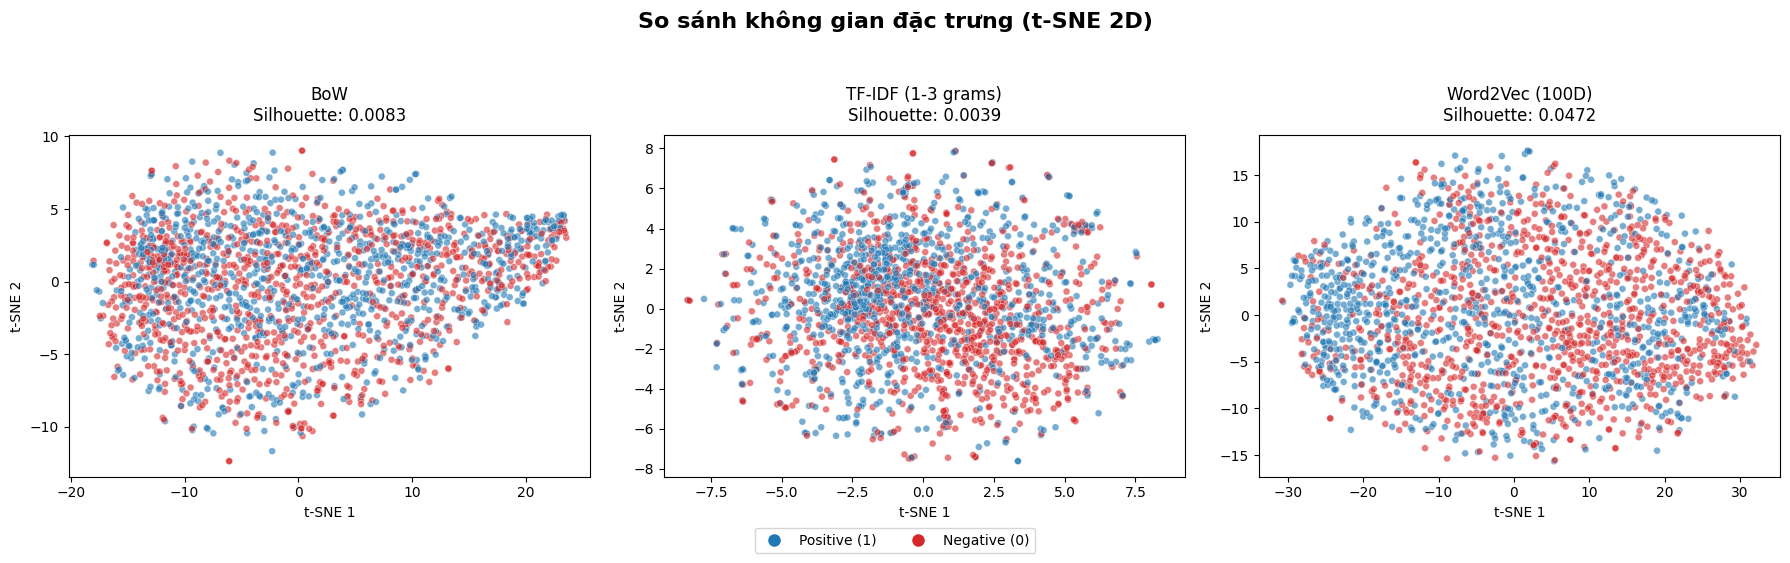

,Phương pháp,Số chiều,Độ thưa (%),Sim tới tâm Pos,Sim tới tâm Neg,Sim giữa 2 tâm,Silhouette Score
0,BoW,"5,000",97.75%,0.7336,0.7332,0.9938,0.0083
1,TF-IDF (1-3 grams),"5,000",96.84%,0.3761,0.3753,0.9763,0.0039
2,Word2Vec (100D),100,0.00%,0.9267,0.9390,0.9927,0.0472


In [24]:
# =====================================================================
# BƯỚC 2: HÀM PHÂN TÍCH VÀ VẼ ĐỒ THỊ LÊN SUBPLOT
# =====================================================================
def analyze_representation_for_summary(X, y, method_name, ax):
    # --- (i) Số chiều và Độ thưa (Sparsity) ---
    n_samples, n_features = X.shape
    if sparse.issparse(X):
        non_zeros = X.nnz
        total_elements = n_samples * n_features
    else:
        non_zeros = np.count_nonzero(X)
        total_elements = X.size
        
    sparsity = 1.0 - (non_zeros / total_elements)
    
    # --- (ii) Cosine Similarity (Centroid Approach) ---
    X_pos = X[y == 1]
    X_neg = X[y == 0]
    
    centroid_pos = np.asarray(X_pos.mean(axis=0)).reshape(1, -1)
    centroid_neg = np.asarray(X_neg.mean(axis=0)).reshape(1, -1)
    
    mean_sim_pos = cosine_similarity(X_pos, centroid_pos).mean()
    mean_sim_neg = cosine_similarity(X_neg, centroid_neg).mean()
    mean_sim_diff = cosine_similarity(centroid_pos, centroid_neg)[0][0]
    
    # --- Silhouette Score (Xấp xỉ trên 5k mẫu) ---
    # Đảm bảo sample_size không vượt quá tổng số mẫu hiện có
    s_size = min(5000, n_samples) 
    sil_score = silhouette_score(X, y, metric='cosine', sample_size=s_size, random_state=42)
    
    # --- (iii) Trực quan hóa t-SNE 2D ---
    n_tsne_samples = min(2000, n_samples)
    np.random.seed(42)
    sample_indices = np.random.choice(n_samples, n_tsne_samples, replace=False)
    X_sample = X[sample_indices]
    y_sample = y[sample_indices]
    
    tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
    
    if sparse.issparse(X_sample):
        X_2d = tsne.fit_transform(X_sample.toarray())
    else:
        X_2d = tsne.fit_transform(X_sample)
        
    # Vẽ lên subplot (ax) được truyền vào
    sns.scatterplot(
        x=X_2d[:, 0], y=X_2d[:, 1], 
        hue=y_sample, palette={1: '#1f77b4', 0: '#d62728'}, 
        alpha=0.6, s=25, ax=ax
    )
    ax.set_title(f'{method_name}\nSilhouette: {sil_score:.4f}', fontsize=12, pad=10)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend_.remove() # Xóa legend từng hình nhỏ để gom lại sau
    
    # Trả về các chỉ số dưới dạng dictionary để tạo bảng
    return {
        "Phương pháp": method_name,
        "Số chiều": f"{n_features:,}",
        "Độ thưa (%)": f"{sparsity * 100:.2f}%",
        "Sim tới tâm Pos": round(mean_sim_pos, 4),
        "Sim tới tâm Neg": round(mean_sim_neg, 4),
        "Sim giữa 2 tâm": round(mean_sim_diff, 4),
        "Silhouette Score": round(sil_score, 4)
    }

# =====================================================================
# THỰC THI VÀ TẠO BẢNG + ĐỒ THỊ
# =====================================================================

# 1. Chuẩn bị khung hình (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results = []

# 2. Chạy hàm cho từng phương pháp và lưu kết quả
results.append(analyze_representation_for_summary(X_bow, y, "BoW", axes[0]))
results.append(analyze_representation_for_summary(X_tfidf, y, "TF-IDF (1-3 grams)", axes[1]))
results.append(analyze_representation_for_summary(X_w2v, y, "Word2Vec (100D)", axes[2]))

# 3. Cấu hình hiển thị đồ thị tổng thể
plt.suptitle('So sánh không gian đặc trưng (t-SNE 2D)', fontsize=16, fontweight='bold', y=1.05)
import matplotlib.lines as mlines
pos_legend = mlines.Line2D([], [], color='#1f77b4', marker='o', linestyle='None', markersize=8, label='Positive (1)')
neg_legend = mlines.Line2D([], [], color='#d62728', marker='o', linestyle='None', markersize=8, label='Negative (0)')
fig.legend(handles=[pos_legend, neg_legend], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

# 4. In bảng tổng hợp bằng Pandas
df_results = pd.DataFrame(results)

df_results

### Phân tích và đánh giá khả năng tách lớp (Silhouette Score và t-SNE)

**Silhouette Score** đo mức độ tách biệt giữa các cụm:
* Giá trị gần **1**: Các điểm cùng lớp nằm sát nhau và cách xa các lớp khác — phân tách lý tưởng.
* Giá trị gần **0**: Các cụm bị chồng chéo nhiều, ranh giới không rõ ràng.
* Giá trị **âm**: Điểm dữ liệu có thể đã bị gán sai cụm.

Cả ba phương pháp đều cho Silhouette Score rất thấp (gần 0). Đây là hiện tượng phổ biến trong bài toán phân tích cảm xúc: hai lớp Positive và Negative không phân tách rõ ràng trong không gian đặc trưng bề mặt — mà sự phân biệt nằm ở các mẫu kết hợp từ phức tạp hơn (cụm từ, ngữ cảnh). Kết quả này tái khẳng định tầm quan trọng của N-gram và Word Embeddings ngữ cảnh (BERT, RoBERTa) ở các bước tiếp theo.